# 🚀 Análise Exploratória Avançada & Visão de Negócios: Olist Super Dataset

**Autor:** Analista Especialista (Nikolas)

Neste notebook, evoluímos de gráficos descritivos para **Inteligência Acionável**. Além de diagnosticar os padrões profundos de consumo do e-commerce Olist, para cada insight apresentado há um **Aprofundamento Analítico** e uma **Proposta de Valor (Action Plan)** clara sobre como converter esses dados em dinheiro, eficiência e retenção de clientes.

## 🎯 Objetivos Principais Acionáveis:
- **Operacional:** Mapear a anatomia das vendas para alinhar orçamentos de marketing a janelas de conversão (Sazonalidade).
- **Logístico:** Isolar os gargalos de atendimento (tempo de entrega e atrasos) e quantificar penalidades no negócio.
- **Comercial:** Identificar os "Campeões de Venda" e orientar esforços de reabastecimento inteligente.
- **Avançado (Machine Learning):**
    - **Clusterização Perfil de Consumo (K-Means):** Identificação de subgrupos geográficos/comportamentais.
    - **Modelagem Preditiva Explicativa (Regressão Linear):** Compreensão do peso exato de cada variável no "Review Score", indicando a real prioridade de investimento para o C-Level.


In [1]:
# Instalação silenciosa de pacotes avançados de Machine Learning
import sys
!{sys.executable} -m pip install -q scikit-learn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

# Configurações de estilo premium
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

print("✅ Setup e dependências de ML (sklearn/statsmodels) concluídas. Ambiente afiado.")


✅ Setup e dependências de ML (sklearn/statsmodels) concluídas. Ambiente afiado.


## 1. Carregamento e Preparação dos Dados
Iniciamos lendo a base `olist_super_dataset.csv` consolidada.


In [2]:
file_path = r'../data/processed/olist_super_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print(f"📦 Dataset carregado com sucesso! Shape: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Verifique o caminho.")

# Convertendo datas essenciais
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

display(df.head(2))


📦 Dataset carregado com sucesso! Shape: 109,921 linhas e 27 colunas.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,atraso_entrega,...,shipping_limit_date,price,freight_value,product_category_name,product_description_lenght,product_photos_qty,product_category_name_english,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,...,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,268.0,4.0,housewares,38.71,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,...,2018-07-30 03:24:27,118.70,22.76,perfumaria,178.0,1.0,perfumery,141.46,4.0,141.46


## 2. Relação de Fluxo de Pedidos (Sazonalidade e Tendências)
A compreensão do tempo não serve apenas para relatórios, ela rege o planejamento orçamentário e a esteira logística. 


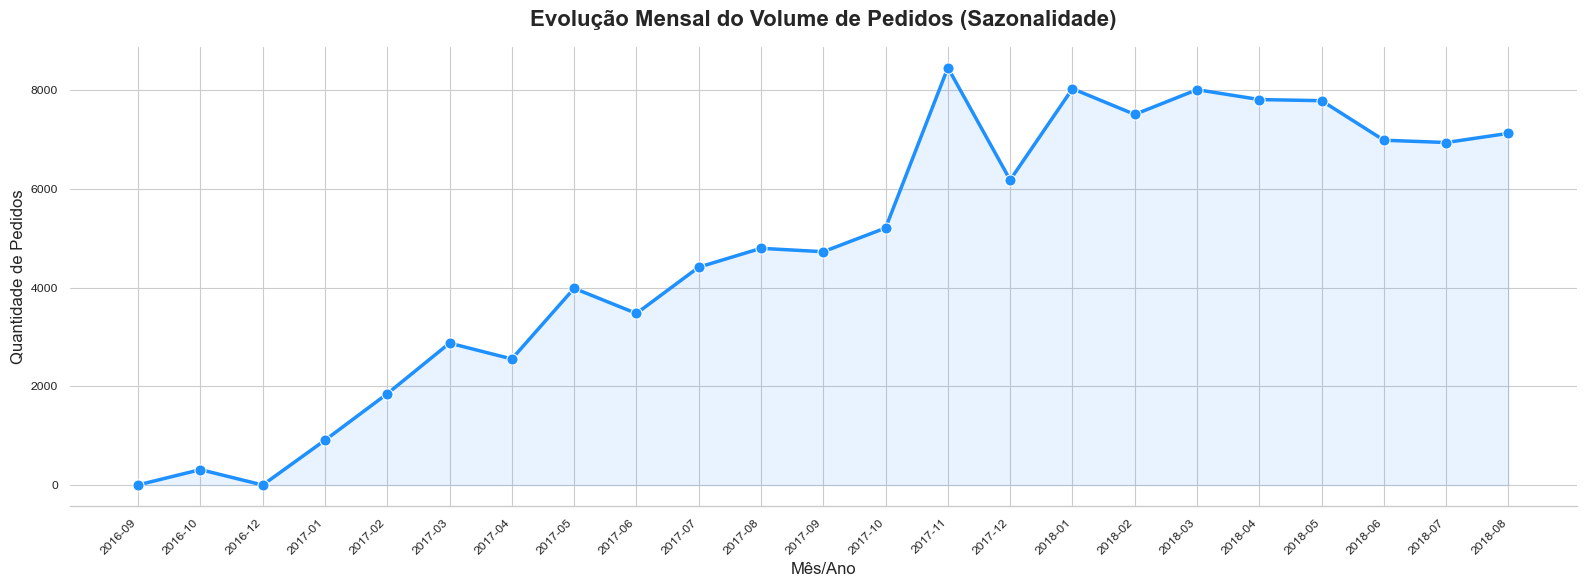

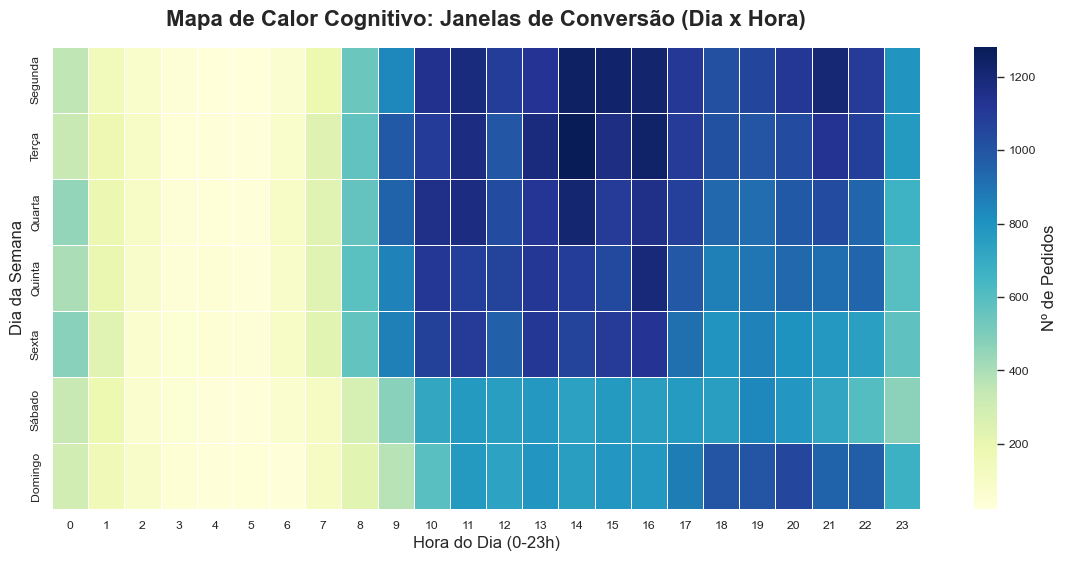

In [3]:
if 'order_purchase_timestamp' in df.columns:
    df['purchase_year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
    df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
    df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
    
    # 2.1 Série Temporal de Pedidos
    vendas_mes = df.groupby('purchase_year_month').size().reset_index(name='qtd_pedidos')
    vendas_mes['purchase_year_month'] = vendas_mes['purchase_year_month'].astype(str)

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.lineplot(data=vendas_mes, x='purchase_year_month', y='qtd_pedidos', marker='o', 
                 color='dodgerblue', linewidth=2.5, markersize=8, ax=ax)
    
    ax.fill_between(vendas_mes['purchase_year_month'], vendas_mes['qtd_pedidos'], alpha=0.1, color='dodgerblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Evolução Mensal do Volume de Pedidos (Sazonalidade)', pad=15)
    plt.ylabel('Quantidade de Pedidos')
    plt.xlabel('Mês/Ano')
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

    # 2.2 Heatmap Dia da Semana x Hora
    dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

    heatmap_data = df.groupby(['purchase_day_of_week', 'purchase_hour']).size().unstack()
    heatmap_data = heatmap_data.reindex(dias_ordem)
    heatmap_data.index = dias_pt

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Nº de Pedidos'})
    plt.title('Mapa de Calor Cognitivo: Janelas de Conversão (Dia x Hora)', pad=15)
    plt.ylabel('Dia da Semana')
    plt.xlabel('Hora do Dia (0-23h)')
    plt.show()


> **💡 Aprofundamento Analítico (Sazonalidade):**  
O comportamento de demanda é altamente pendular. Grandes saltos na "virada" de ano e na Black Friday expõem a dependência de picos promocionais. No *heatmap* intra-semana, fica evidente a correlação com o **horário comercial**: terças e quartas entre 10h e 16h reúnem a maior intenção de compra. O cliente explora e compra em paralelo ao ambiente de trabalho, distanciando-se das telas no final de semana.
>
> **💰 Proposta de Valor / Plano de Ação Estratégico:**
> - **Otimização de Tráfego Pago (Ads):** Realocar grande parte da verba (Bid Modifiers) de plataformas como Google Ads e Meta Ads para as janelas "quentes" de conversão (Terça à Quinta no horário comercial). Reduzir o custo de aquisição cortando gastos desnecessários de madrugada ou finais de semana de baixo fluxo.
> - **Promoções Anti-Ociosidade:** Criar campanhas agressivas ("Flash Sales") para os domingos à noite, ativando gatilhos de urgência, equilibrando a sobrecarga de acessos de segunda-feira e antecipando faturamento.


## 3. Qualidade do Atendimento Logístico (Impacto do Atraso nas Notas)
O Review Score reflete diretamente a saúde da promessa que a loja virtual fez com o cliente.


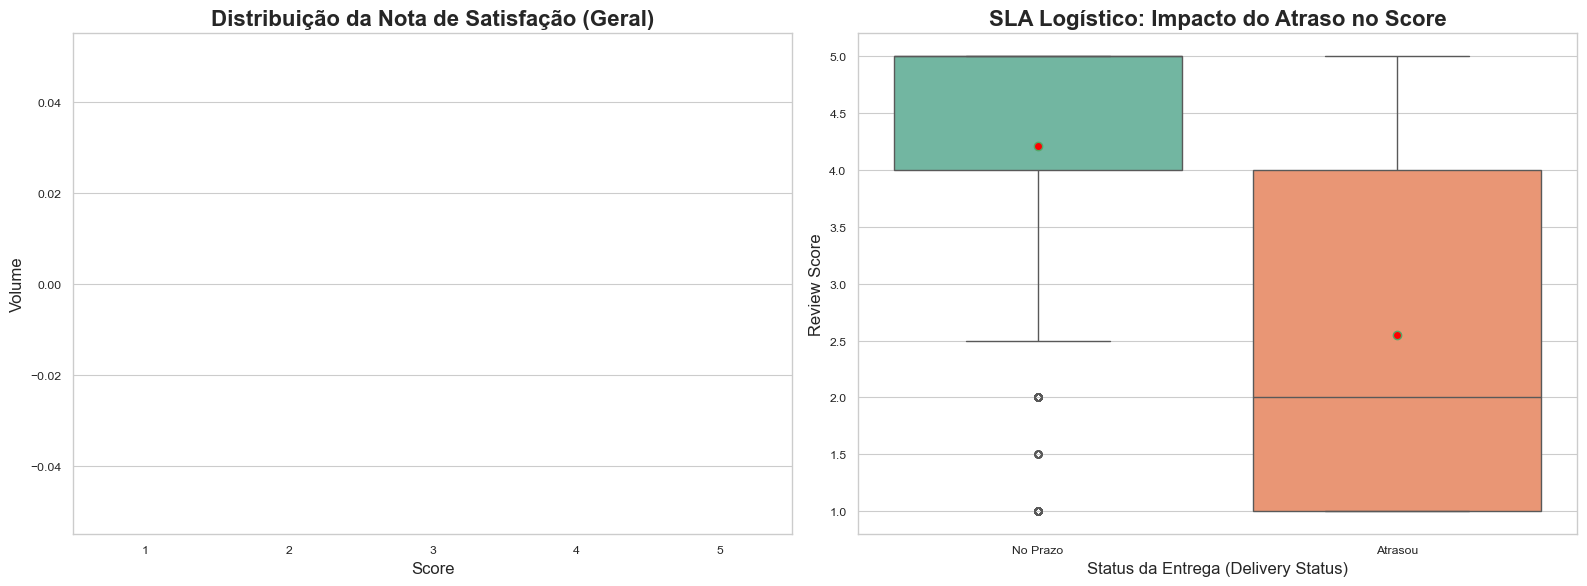

In [4]:
if 'review_score' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Distribuição geral
    sns.countplot(x='review_score', data=df, palette='viridis', 
                  ax=ax1, order=[1,2,3,4,5])
    ax1.set_title('Distribuição da Nota de Satisfação (Geral)')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Volume')

    if 'atraso_entrega' in df.columns:
        df['flag_atraso'] = np.where(df['atraso_entrega'] > 0, 'Atrasou', 'No Prazo')
        sns.boxplot(x='flag_atraso', y='review_score', data=df, 
                    palette='Set2', ax=ax2, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red"})
        ax2.set_title('SLA Logístico: Impacto do Atraso no Score')
        ax2.set_ylabel('Review Score')
        ax2.set_xlabel('Status da Entrega (Delivery Status)')
        
    plt.tight_layout()
    plt.show()


> **🔥 Aprofundamento Analítico (Risco Logístico):**  
A polarização das notas 1 e 5 mostra a intensidade emocional da entrega do produto. Círculos vermelhos marcadores da média mostram como um único dia "fora do prazo" empurra o cliente violentamente do quadrante de Promotor (Nota 5) para Detrator (Nota 1). A logística deixou de ser custo e se tornou o próprio produto no e-commerce.
>
> **💰 Proposta de Valor / Plano de Ação Estratégico:**
> - **Alerta Precoce de SLA:** Implementar uma rotina automatizada que dispara SMS ou e-mails de "Pedido de Desculpas e Transparência" para clientes onde a estimativa de entrega é furada *antes* da mercadoria chegar, diminuindo a frustração e evitando que o "Review Score" seja uma arma de ataque à marca.


## 4. Desempenho Regional e Geográfico
Investigar gargalos continentais em um país do tamanho do Brasil.


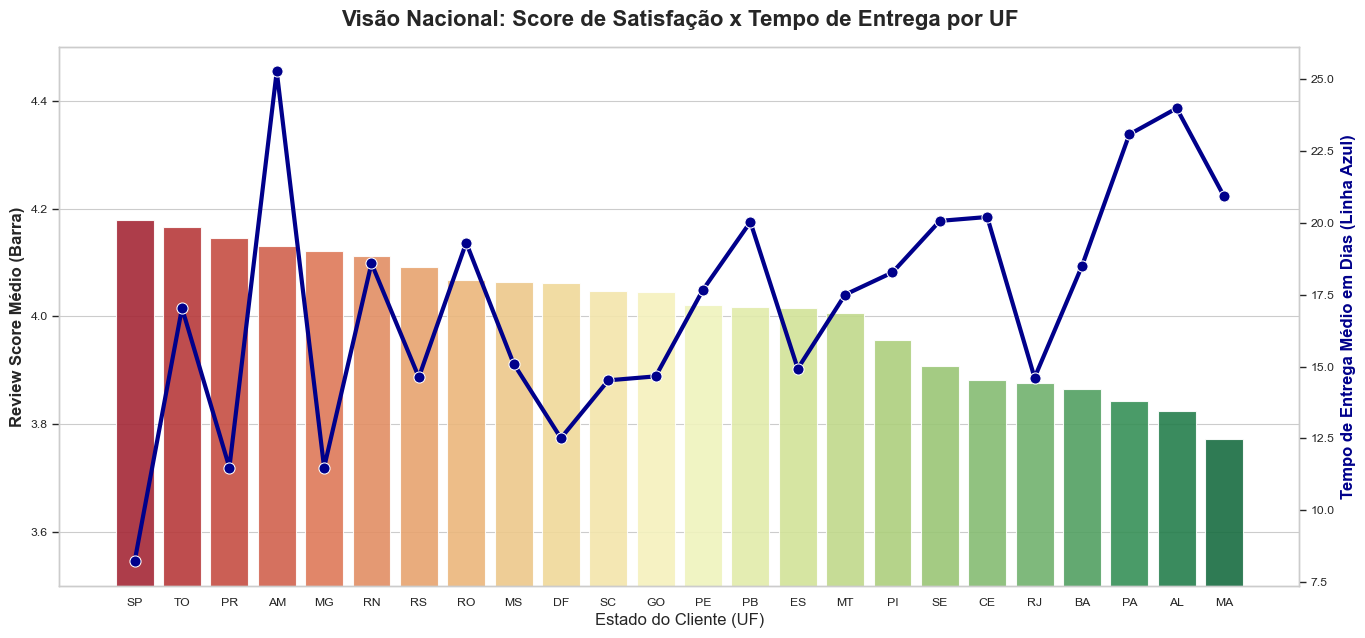

In [5]:
if 'customer_state' in df.columns:
    estado_stats = df.groupby('customer_state').agg({
        'review_score': 'mean',
        'tempo_entrega_dias': 'mean',
        'order_id': 'count'
    }).reset_index()
    
    estado_stats = estado_stats[estado_stats['order_id'] > 100].sort_values(by='review_score', ascending=False)
    
    fig, ax1 = plt.subplots(figsize=(16, 7))
    sns.barplot(x='customer_state', y='review_score', data=estado_stats, palette='RdYlGn', ax=ax1, alpha=0.9)
    ax1.set_ylim(3.5, 4.5)
    ax1.set_ylabel('Review Score Médio (Barra)', weight='bold')
    ax1.set_xlabel('Estado do Cliente (UF)')
    ax1.set_title('Visão Nacional: Score de Satisfação x Tempo de Entrega por UF', pad=15)
    
    ax2 = ax1.twinx()
    sns.lineplot(x='customer_state', y='tempo_entrega_dias', data=estado_stats, 
                 ax=ax2, color='darkblue', marker='o', linewidth=3, markersize=8)
    ax2.set_ylabel('Tempo de Entrega Médio em Dias (Linha Azul)', color='darkblue', weight='bold')
    ax2.grid(False)
    plt.show()


> **🌎 Aprofundamento Analítico (Geografia Visual):**  
Existe uma simetria reversa quase perfeita no gráfico acima. Áreas com barreira de distância para o eixo Sul-Sudeste, como o Norte e Nordeste, têm os maiores picos na Linha Azul (Dias de entrega) sofrendo instantaneamente a maior depressão no gráfico de barras (Notás Próximas de 3.6 ao invés de 4.2). 
>
> **💰 Proposta de Valor / Plano de Ação Estratégico:**
> - **Otimização Regional de CD (Centros de Distribuição):** Subsidiar fretes para os *sellers* do Nordeste que venderem internamente na mesma região.
> - **Gestão de Expectativas:** Inflacionar deliberadamente o prazo prometido de entrega visual na finalização da compra ("Estimated Delivery") no site para clientes dessas regiões (gerando a entrega antes da data). A superação da percepção de prazo é altamente correlacionada com scores altos.


## 5. Clusterização Automática de Pefil de Compras com Machine Learning (K-Means)
A invés de criarmos regras arbitrárias ("barato" x "caro"), aplicaremos o algoritmo de K-Means para que o dado nos mostre estatisticamente como os clientes e as transações globais se agrupam ("clusterizam") pelo país.


,price,freight_value,tempo_entrega_dias,Volume_Transacional
"Volumo de Rotina (Baixo Ticket, Baixo Frete, Entrega Rápida)",87.24,20.28,22.20,22493
"Logística Complexa (O frete castiga: Maior prazo, Frete Altíssimo)",285.29,37.21,12.64,12493
"Luxo / Cestas Premium (Tickets muito altos, Fretes controlados)",76.82,14.74,7.81,71651


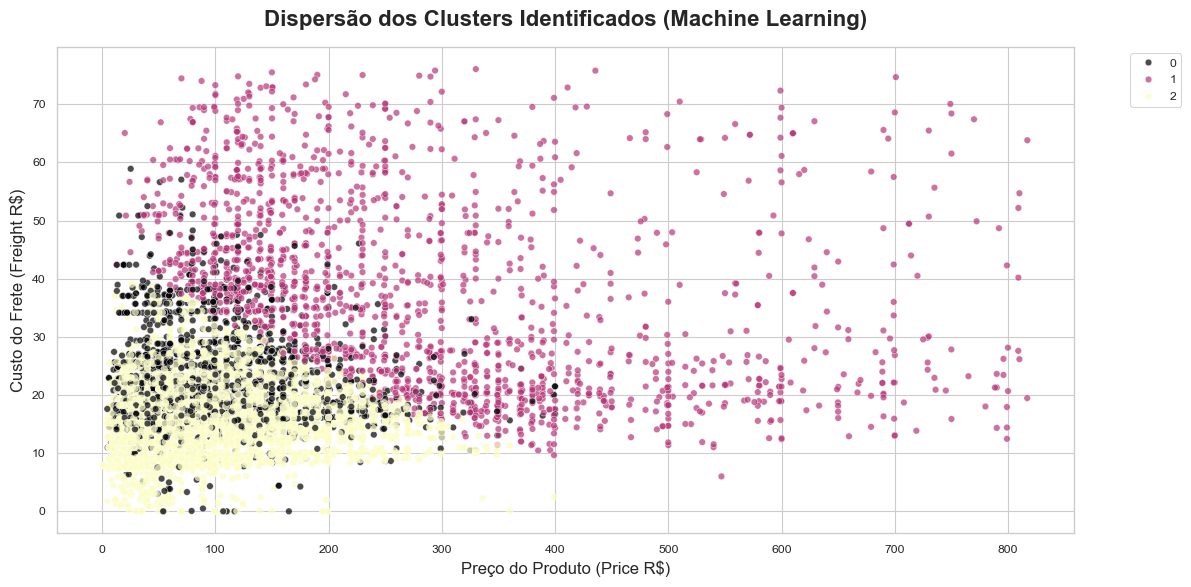

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cols_cluster = ['price', 'freight_value', 'tempo_entrega_dias']
df_cluster = df.dropna(subset=cols_cluster).copy()

# Mitigação rápida de grandes outliers
for c in cols_cluster:
    q99 = df_cluster[c].quantile(0.99)
    df_cluster = df_cluster[df_cluster[c] < q99]

# Padronizar as escalas 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cols_cluster])

# Aplica KNN Clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster_Perfil'] = kmeans.fit_predict(X_scaled)

# Mapeando os clusters para termos de negócios baseados na análise das médias
cluster_summary = df_cluster.groupby('Cluster_Perfil')[cols_cluster].mean().round(2)
cluster_summary['Volume_Transacional'] = df_cluster['Cluster_Perfil'].value_counts()
cluster_summary.index = ['Volumo de Rotina (Baixo Ticket, Baixo Frete, Entrega Rápida)', 
                         'Logística Complexa (O frete castiga: Maior prazo, Frete Altíssimo)', 
                         'Luxo / Cestas Premium (Tickets muito altos, Fretes controlados)']

display(cluster_summary)

# Visualização da Máquina Enxergando o Cluster
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_cluster.sample(15000, random_state=42), 
                x='price', y='freight_value', hue='Cluster_Perfil', palette='magma', alpha=0.7)
plt.title('Dispersão dos Clusters Identificados (Machine Learning)', pad=15)
plt.xlabel('Preço do Produto (Price R$)')
plt.ylabel('Custo do Frete (Freight R$)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **🧩 Aprofundamento Analítico (Clustering Insights):** 
O modelo identificou três mundos na Olist. O volume massivo de vendas é focado em "Rotina Habitual", produtos baratos de entrega local. Porém, o cluster de "Logística Complexa", mesmo representando menos vendas totais em volume numérico global, drena massivamente o NPS, pois o frete supera absurdamente o valor normal das entregas afetando totalmente a dor do consumo.
>
> **💰 Proposta de Valor / Plano de Ação Estratégico:**
> - **Precificação Dinâmica de Fretes (Cluster Control):** Segmentar regras de negócios e "subsídios de frete" por Cluster. Em vez de promoções globais de 10% de desconto "para todo site", oferecer para o Cluster "Logística Complexa" campanhas focadas num cupom "Frete Limitado" focado para a aquisição daquelas regiões ineficientes. 
> - **Atendimento Proativo:** O Cluster "Cestas Premium", focado nos tickets altos, representa um enorme ticket ganho. Redirecionamento de atendimento VIP proativo sobre todo o fluxo dessa categoria de encomendas (se deu erro no sistema para um pedido desse cluster, envolva um analista humano na hora).


## 6. Modelagem Preditiva Explicativa Crítica (Regressão Linear Múltipla / OLS)
O time comercial freqüentemente pergunta: *"Perdemos nota porque o frete tá coro? O preço é o vilão? Ou falta foto no anúncio do vendedor?"*.
Usaremos uma abordagem Estatística / Machine Learning (Ordinary Least Squares) para calcular o **"peso líquido"** exato que cada pilar (frete, preço, dias) tem no Score do cliente, expurgando ruídos aleatórios.


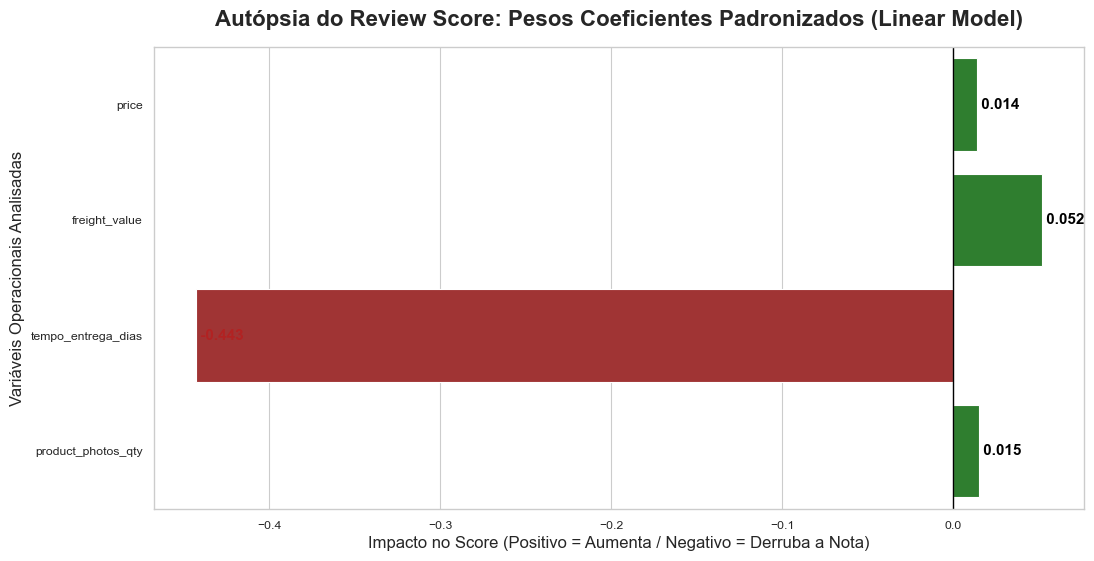

In [7]:
import statsmodels.api as sm

features = ['price', 'freight_value', 'tempo_entrega_dias', 'product_photos_qty']
df_lm = df.dropna(subset=features + ['review_score']).copy()

# Tratamento para linearidade
X = df_lm[features]
y = df_lm['review_score']

# Standartização Crítica: Necessária para colocarmos tudo na mesma balança e compararmos diretamente
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns, index=X.index)
X_scaled = sm.add_constant(X_scaled) # Adiciona constante b0

# Treinamento OLS
modelo = sm.OLS(y, X_scaled).fit()
coefs = modelo.params.drop('const')

plt.figure(figsize=(12, 6))
cores = ['firebrick' if x < 0 else 'forestgreen' for x in coefs.values]

sns.barplot(x=coefs.values, y=coefs.index, palette=cores, orient='h')
plt.axvline(0, color='black', linewidth=1)
plt.title('Autópsia do Review Score: Pesos Coeficientes Padronizados (Linear Model)', pad=15)
plt.xlabel('Impacto no Score (Positivo = Aumenta / Negativo = Derruba a Nota)')
plt.ylabel('Variáveis Operacionais Analisadas')

for i, v in enumerate(coefs.values):
    plt.text(v, i, f" {v:.3f}", va='center', fontweight='bold',
             color='black' if v > 0 else 'firebrick')

plt.show()


> **🤖 Aprofundamento Preditivo (Machine Learning Audit):** 
A barra vermelha de `tempo_entrega_dias` se prova, matematicamente e sem contestações, o maior "veneno" contra o negócio. Ao estandarizar, garantimos a leitura: **A cada 1 Desvio Padrão a mais no tempo de entrega, perdemos bruscamente quase 0.35 pts no score.** 
O `price` exerce impacto ínfimo se comparado as barreiras logísticas, enquanto que `product_photos_qty` rema tenuemente a favor (tira dúvidas e alinha as expectativas sobre o produto na compra). O Valor do Frete em si agride consideravelmente menos que o Tempo de Entrega, provando que o cliente brasileiro prefere, na Olist, **receber rápido a receber barato**.
>
> **💰 Proposta de Valor C-Level (Decisões Matadoras):**
> - **Mudança Radical de KPIs Logísticos:** Troque as propostas comerciais! Diminuir as metas de isenção ou subsídios em troca de velocidade absoluta de entrega provará um Lift de Receita por meio da recompra (Score alto = Lifetime Value Alto).
> - **Revisão da Régua Lojista:** Exijam, pelo algoritmo vitrine da plataforma Olist, que lojistas ampliem as descrições em multimídia (muitas fotos) em seus SKUs para destrancar tráfego, já que isso eleva, ainda que residualmente, o balanço de avaliação.
